In [42]:
"""
Script 3 — cc3d Wind Blob Tracking (per-year output)
=====================================================
Reads the per-category masked wind speed files from Script 2, binarises
via np.isfinite(), and tracks spatiotemporally contiguous wind objects
across 1979–2024, Apr–Sep. Saves one NetCDF + one CSV per year.

Set TARGET_CATEGORY in USER SETTINGS to track any of the five categories:
  0 = none (calm, 0–3.5 m/s)
  1 = low        (3.5–6.5 m/s)
  2 = medium     (6.5–12.0 m/s)
  3 = rated      (12.0–23.0 m/s)
  4 = cut_out    (>23.0 m/s)

Output per year:
  wind_events_{label}_{year}.nc
  wind_event_statistics_{label}_{year}.csv
"""

import os
import glob
import cc3d
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime


# ------------------------------------------------------------------ #
#  USER SETTINGS
# ------------------------------------------------------------------ #

FLAG_DIR   = "/g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_speed_cats/"
FLAG_GLOB  = "barra_wind_cat{cat_id}_{label}_*.nc"

OUTPUT_DIR = "/g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_cc3d/"

LAND_MASK_FILE = (
    "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/"
    "BARRA-R2/v1/fx/sftlf/latest/sftlf_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1.nc"
)
LAND_MASK_VAR = "sftlf"

YEAR_START = 2010
YEAR_END   = 2010


TARGET_CATEGORY = 0  # 0=none, 1=low, 2=medium, 3=rated, 4=cut_out

CATEGORY_LABELS = {0: "none", 1: "low", 2: "medium", 3: "rated", 4: "cut_out"}
CATEGORY_RANGES = {0: "0–3.5", 1: "3.5–6.5", 2: "6.5–12.0",
                   3: "12.0–23.0", 4: ">23.0"}

MIN_DURATION_DAYS        = 1
MIN_AREA_DAILY_KM2       = 400_000.0
MIN_AREA_LIFETIME_KM2    = 400_000.0
MIN_AREA_DAILY_EVENT_KM2 = 400_000.0
MAX_DISPLACEMENT_KM      = 100000000.0

CONNECTIVITY  = 26
SKIP_EXISTING = True


# ------------------------------------------------------------------ #
#  HELPERS  (unchanged from previous version)
# ------------------------------------------------------------------ #

def compute_grid_cell_area_km2(lat, lon):
    R    = 6371.0
    dlat = np.deg2rad(abs(np.diff(lat).mean()))
    dlon = np.deg2rad(abs(np.diff(lon).mean()))
    area_row = R**2 * np.abs(np.cos(np.deg2rad(lat))) * dlat * dlon
    return np.tile(area_row[:, np.newaxis], (1, len(lon)))


def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.deg2rad(lat2 - lat1)
    dlon = np.deg2rad(lon2 - lon1)
    a    = (np.sin(dlat / 2)**2
            + np.cos(np.deg2rad(lat1)) * np.cos(np.deg2rad(lat2))
            * np.sin(dlon / 2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))


def year_from_path(p):
    return int(os.path.basename(p).replace(".nc", "").split("_")[-1])


def load_land_mask(mask_file, mask_var, target_lat, target_lon):
    ds_mask  = xr.open_dataset(mask_file)
    sftlf    = ds_mask[mask_var]
    lat_vals = sftlf.lat.values
    lat_slice = (
        slice(target_lat.max(), target_lat.min()) if lat_vals[0] > lat_vals[-1]
        else slice(target_lat.min(), target_lat.max())
    )
    sftlf_sub    = sftlf.sel(lat=lat_slice,
                              lon=slice(target_lon.min(), target_lon.max()))
    sftlf_regrid = sftlf_sub.interp(lat=target_lat, lon=target_lon,
                                     method="nearest")
    land_frac = sftlf_regrid.values
    threshold = 50.0 if np.nanmax(land_frac) > 1.0 else 0.5
    land_bool = land_frac > threshold
    print(f"  Land cells: {land_bool.sum():,} / {land_bool.size:,} "
          f"({100 * land_bool.mean():.1f}%)")
    ds_mask.close()
    return land_bool


def apply_daily_area_threshold(binary, area_2d):
    out       = binary.copy()
    n_removed = 0
    for t in range(binary.shape[0]):
        day_mask = binary[t].astype(bool)
        if not day_mask.any():
            continue
        if area_2d[day_mask].sum() < MIN_AREA_DAILY_KM2:
            out[t]    = 0
            n_removed += 1
    print(f"  Daily area pre-filter: removed {n_removed} / {binary.shape[0]} days")
    return out


def filter_events(labels_raw, area_2d, land_mask):
    stats  = cc3d.statistics(labels_raw)
    voxels = stats["voxel_counts"]
    bboxes = stats["bounding_boxes"]
    out    = labels_raw.copy()
    removed = {"duration": 0, "area": 0, "land": 0, "daily_event_area": 0}

    for lbl in range(1, len(voxels)):
        if voxels[lbl] == 0:
            continue
        bb                 = bboxes[lbl]
        t_sl, la_sl, lo_sl = bb[0], bb[1], bb[2]
        sub_mask           = (labels_raw[t_sl, la_sl, lo_sl] == lbl)
        sub_area           = area_2d[la_sl, lo_sl]
        sub_land           = land_mask[la_sl, lo_sl]
        active             = np.where(sub_mask.any(axis=(1, 2)))[0]

        if len(active) < MIN_DURATION_DAYS:
            out[labels_raw == lbl] = 0; removed["duration"] += 1; continue
        if max(sub_area[sub_mask[t]].sum() for t in active) < MIN_AREA_LIFETIME_KM2:
            out[labels_raw == lbl] = 0; removed["area"] += 1; continue
        if not any(sub_land[sub_mask[t]].any() for t in active):
            out[labels_raw == lbl] = 0; removed["land"] += 1; continue

        bad_days = [t for t in active
                    if sub_area[sub_mask[t]].sum() < MIN_AREA_DAILY_EVENT_KM2]
        if not bad_days:
            continue

        removed["daily_event_area"] += 1
        for t in bad_days:
            t_abs      = t_sl.start + t
            rows, cols = np.where(sub_mask[t])
            for r, c in zip(rows, cols):
                out[t_abs, la_sl.start + r, lo_sl.start + c] = 0

        surviving = sorted(set(active) - set(bad_days))
        if not surviving:
            continue

        fragments = []
        frag = [surviving[0]]
        for d in surviving[1:]:
            if d == frag[-1] + 1:
                frag.append(d)
            else:
                fragments.append(frag); frag = [d]
        fragments.append(frag)

        for i, frag_days in enumerate(fragments):
            frag_mask = np.zeros_like(sub_mask)
            for t in frag_days:
                frag_mask[t] = sub_mask[t]
            keep = (
                len(frag_days) >= MIN_DURATION_DAYS
                and max(sub_area[frag_mask[t]].sum() for t in frag_days) >= MIN_AREA_LIFETIME_KM2
                and any(sub_land[frag_mask[t]].any() for t in frag_days)
            )
            if not keep:
                for t in frag_days:
                    t_abs      = t_sl.start + t
                    rows, cols = np.where(frag_mask[t])
                    for r, c in zip(rows, cols):
                        out[t_abs, la_sl.start + r, lo_sl.start + c] = 0
            elif i > 0:
                new_lbl = int(out.max()) + 1
                for t in frag_days:
                    t_abs      = t_sl.start + t
                    rows, cols = np.where(frag_mask[t])
                    for r, c in zip(rows, cols):
                        out[t_abs, la_sl.start + r, lo_sl.start + c] = new_lbl

    print(f"  Removed — duration: {removed['duration']}  area: {removed['area']}  "
          f"land: {removed['land']}  daily_event_area: {removed['daily_event_area']}")
    return out


def apply_displacement_split(labels, area_2d, land_mask, lat, lon):
    out         = labels.copy()
    next_label  = int(labels.max()) + 1
    n_splits    = 0
    n_discarded = 0

    for lbl in np.unique(labels[labels != 0]):
        event_times = np.where((labels == lbl).any(axis=(1, 2)))[0]
        if len(event_times) < 2:
            continue
        centroids = []
        for t in event_times:
            mask_t             = labels[t] == lbl
            lats_idx, lons_idx = np.where(mask_t)
            weights            = area_2d[lats_idx, lons_idx]
            centroids.append((
                float(np.average(lat[lats_idx], weights=weights)),
                float(np.average(lon[lons_idx], weights=weights)),
            ))

        split_indices = [
            i for i in range(1, len(centroids))
            if haversine_km(*centroids[i - 1], *centroids[i]) > MAX_DISPLACEMENT_KM
        ]
        if not split_indices:
            continue

        boundaries = [0] + split_indices + [len(event_times)]
        fragments  = [event_times[boundaries[i]:boundaries[i + 1]]
                      for i in range(len(boundaries) - 1)]
        n_splits  += len(split_indices)

        for frag_idx, frag_times in enumerate(fragments):
            new_lbl = lbl if frag_idx == 0 else next_label
            if frag_idx > 0:
                next_label += 1
                for t in frag_times:
                    out[t][labels[t] == lbl] = new_lbl

            frag_area = max(area_2d[out[t] == new_lbl].sum() for t in frag_times)
            has_land  = any(land_mask[out[t] == new_lbl].any() for t in frag_times)
            if (len(frag_times) < MIN_DURATION_DAYS
                    or frag_area < MIN_AREA_LIFETIME_KM2
                    or not has_land):
                for t in frag_times:
                    out[t][out[t] == new_lbl] = 0
                n_discarded += 1

    print(f"  Displacement splits: {n_splits}  |  "
          f"Fragments discarded after split: {n_discarded}")
    return out


def compute_statistics(labels, ws_masked, times, lat, lon, area_2d, land_mask):
    stats_cc3d = cc3d.statistics(labels)
    bboxes     = stats_cc3d["bounding_boxes"]
    rows       = []

    for lbl in np.unique(labels[labels != 0]):
        bb                 = bboxes[lbl]
        t_sl, la_sl, lo_sl = bb[0], bb[1], bb[2]
        sub_mask           = (labels[t_sl, la_sl, lo_sl] == lbl)
        sub_area           = area_2d[la_sl, lo_sl]
        sub_land           = land_mask[la_sl, lo_sl]
        sub_lat            = lat[la_sl]
        sub_lon            = lon[lo_sl]
        sub_ws             = ws_masked[t_sl, la_sl, lo_sl]

        t_local  = np.where(sub_mask.any(axis=(1, 2)))[0]
        t_global = t_local + t_sl.start
        n_days   = len(t_local)

        daily_areas, centroids     = [], []
        daily_mean_ws, daily_max_ws = [], []

        for tl in t_local:
            sm      = sub_mask[tl]
            weights = sub_area[sm]
            daily_areas.append(float(weights.sum()))
            centroids.append((
                float(np.average(sub_lat[np.where(sm)[0]], weights=weights)),
                float(np.average(sub_lon[np.where(sm)[1]], weights=weights)),
            ))
            ws_vals = sub_ws[tl][sm]
            finite  = np.isfinite(ws_vals)
            if finite.any():
                daily_mean_ws.append(float(np.average(ws_vals[finite],
                                                       weights=weights[finite])))
                daily_max_ws.append(float(ws_vals[finite].max()))
            else:
                daily_mean_ws.append(np.nan)
                daily_max_ws.append(np.nan)

        daily_land_areas = [
            float(sub_area[sub_mask[tl] & sub_land].sum()) for tl in t_local
        ]

        mean_disp = float(np.mean([
            haversine_km(*centroids[i], *centroids[i + 1])
            for i in range(len(centroids) - 1)
        ])) if n_days > 1 else np.nan

        mean_overlap = float(np.mean([
            np.logical_and(sub_mask[t_local[i - 1]], sub_mask[t_local[i]]).sum() /
            max(np.logical_or(sub_mask[t_local[i - 1]], sub_mask[t_local[i]]).sum(), 1)
            for i in range(1, n_days)
        ])) if n_days > 1 else np.nan

        valid_means = [v for v in daily_mean_ws if not np.isnan(v)]
        valid_maxes = [v for v in daily_max_ws  if not np.isnan(v)]

        rows.append({
            "event_id":                  int(lbl),
            "start_date":                pd.Timestamp(times[t_global[0]]).date(),
            "end_date":                  pd.Timestamp(times[t_global[-1]]).date(),
            "duration_days":             n_days,
            "mean_daily_area_km2":       round(float(np.mean(daily_areas)), 2),
            "max_daily_area_km2":        round(float(np.max(daily_areas)), 2),
            "total_area_km2":            round(float(np.sum(daily_areas)), 2),
            "max_land_area_km2":         round(float(np.max(daily_land_areas)), 2),
            "mean_land_area_km2":        round(float(np.mean(daily_land_areas)), 2),
            "mean_centroid_lat":         round(float(np.mean([c[0] for c in centroids])), 4),
            "mean_centroid_lon":         round(float(np.mean([c[1] for c in centroids])), 4),
            "mean_displacement_km_day":  round(mean_disp, 2) if not np.isnan(mean_disp) else np.nan,
            "mean_overlap_fraction":     round(mean_overlap, 4) if not np.isnan(mean_overlap) else np.nan,
            "mean_wind_speed_ms":        round(float(np.mean(valid_means)), 3) if valid_means else np.nan,
            "max_wind_speed_ms":         round(float(np.max(valid_maxes)),  3) if valid_maxes else np.nan,
            "mean_daily_max_ws_ms":      round(float(np.mean(valid_maxes)), 3) if valid_maxes else np.nan,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------------ #
#  MAIN — per-year loop
# ------------------------------------------------------------------ #

os.makedirs(OUTPUT_DIR, exist_ok=True)

label     = CATEGORY_LABELS[TARGET_CATEGORY]
cat_range = CATEGORY_RANGES[TARGET_CATEGORY]
print(f"Tracking category {TARGET_CATEGORY} — '{label}'  ({cat_range} m/s)")

# Collect all available files for this category, filtered to year range
pattern   = FLAG_GLOB.format(cat_id=TARGET_CATEGORY, label=label)
all_files = sorted(glob.glob(os.path.join(FLAG_DIR, pattern)))
all_files = [f for f in all_files if YEAR_START <= year_from_path(f) <= YEAR_END]

if not all_files:
    raise FileNotFoundError(
        f"No files found matching {os.path.join(FLAG_DIR, pattern)}\n"
        f"for {YEAR_START}–{YEAR_END}. Run Script 2 first."
    )

# Build year → file mapping
year_file_map = {year_from_path(f): f for f in all_files}

# Load land mask once from the first file's grid
print("\nLoading land mask (one-time) ...")
_ref    = xr.open_dataset(all_files[0])
lat_ref = _ref["lat"].values
lon_ref = _ref["lon"].values
_ref.close()

land_mask = load_land_mask(LAND_MASK_FILE, LAND_MASK_VAR, lat_ref, lon_ref)
area_2d   = compute_grid_cell_area_km2(lat_ref, lon_ref)

# ------------------------------------------------------------------ #
#  YEAR LOOP
# ------------------------------------------------------------------ #

for year in range(YEAR_START, YEAR_END + 1):

    if year not in year_file_map:
        print(f"\n{year}: no input file found — skipping.")
        continue

    nc_path  = os.path.join(OUTPUT_DIR, f"wind_events_{label}_{year}.nc")
    csv_path = os.path.join(OUTPUT_DIR, f"wind_event_statistics_{label}_{year}.csv")

    if SKIP_EXISTING and os.path.exists(nc_path) and os.path.exists(csv_path):
        print(f"{year}: skipping — outputs already exist.")
        continue

    print(f"\n{'='*55}\n  {year}  |  category {TARGET_CATEGORY} ({label})\n{'='*55}")

    # Load single year
    ds        = xr.open_dataset(year_file_map[year]).load()
    times     = ds["time"].values
    lat       = ds["lat"].values
    lon       = ds["lon"].values
    ws_masked = ds["wind_speed_masked"].values
    ds.close()

    print(f"  {len(times)} time steps  |  {len(lat)} lat × {len(lon)} lon")

    # Binarise
    binary = np.isfinite(ws_masked).astype(np.int32)
    print(f"  Fraction of cells in category: {binary.mean() * 100:.1f}%")

    # Step 1 — pre-cc3d daily area filter
    binary = apply_daily_area_threshold(binary, area_2d)

    # Step 2 — cc3d
    print(f"  Running cc3d (connectivity={CONNECTIVITY}) ...")
    labels_raw = cc3d.connected_components(binary, connectivity=CONNECTIVITY)
    print(f"  Raw objects: {int(labels_raw.max())}")

    # Steps 3–6 — filters + displacement split
    print("  Filtering events ...")
    labels_filtered = filter_events(labels_raw, area_2d, land_mask)

    print(f"  Running displacement split (max={MAX_DISPLACEMENT_KM:.0f} km) ...")
    labels_filtered = apply_displacement_split(
        labels_filtered, area_2d, land_mask, lat, lon
    )

    # Relabel sequentially from 1
    unique_ids  = np.unique(labels_filtered[labels_filtered != 0])
    labels_seq  = np.zeros_like(labels_filtered)
    for new_id, old_id in enumerate(unique_ids, start=1):
        labels_seq[labels_filtered == old_id] = new_id
    labels_filtered = labels_seq

    n_kept = int(labels_filtered.max())
    print(f"  Final event count: {n_kept}")

    if n_kept == 0:
        print("  No events passed filters — skipping output.")
        continue

    # Statistics
    print("  Computing statistics ...")
    stats_df = compute_statistics(
        labels_filtered, ws_masked, times, lat, lon, area_2d, land_mask
    )

    # Save NetCDF
    xr.DataArray(
        labels_filtered.astype(np.int32),
        dims=["time", "lat", "lon"],
        coords={"time": xr.open_dataset(year_file_map[year])["time"],
                "lat":  lat, "lon": lon},
        name="wind_event_id",
        attrs={
            "long_name":                f"Wind event ID — category {TARGET_CATEGORY} ({label})",
            "category_id":              TARGET_CATEGORY,
            "category_label":           label,
            "speed_range_ms":           cat_range,
            "year":                     year,
            "min_duration_days":        MIN_DURATION_DAYS,
            "min_area_daily_km2":       MIN_AREA_DAILY_KM2,
            "min_area_lifetime_km2":    MIN_AREA_LIFETIME_KM2,
            "min_area_daily_event_km2": MIN_AREA_DAILY_EVENT_KM2,
            "max_displacement_km":      MAX_DISPLACEMENT_KM,
            "connectivity":             CONNECTIVITY,
            "created":                  datetime.now().strftime("%Y-%m-%d %H:%M"),
        },
    ).to_dataset().to_netcdf(
        nc_path,
        encoding={"wind_event_id": {"dtype": "int32", "zlib": True, "complevel": 4}},
    )
    print(f"  NetCDF  → {nc_path}")

    stats_df.to_csv(csv_path, index=False)
    print(f"  CSV     → {csv_path}")

print("\nAll years complete.")

Tracking category 0 — 'none'  (0–3.5 m/s)

Loading land mask (one-time) ...
  Land cells: 8,302 / 19,397 (42.8%)

  2010  |  category 0 (none)
  183 time steps  |  119 lat × 163 lon
  Fraction of cells in category: 19.0%
  Daily area pre-filter: removed 90 / 183 days
  Running cc3d (connectivity=26) ...
  Raw objects: 309
  Filtering events ...
  Removed — duration: 0  area: 277  land: 0  daily_event_area: 5
  Running displacement split (max=100000000 km) ...
  Displacement splits: 0  |  Fragments discarded after split: 0
  Final event count: 32
  Computing statistics ...
  NetCDF  → /g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_cc3d/1wind_events_none_2010.nc
  CSV     → /g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_cc3d/1wind_event_statistics_none_2010.csv

All years complete.


Loading /g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_cc3d/Tests/wind_events_none_2010_15.nc
Loading /g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_speed_cats/barra_wind_cat0_none_2010.nc

Event 1 — 1 active days
  Start : 2010-04-01
  End   : 2010-04-01


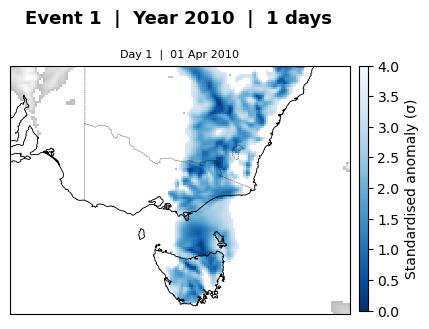

In [35]:
"""
inspect_events.py
=================
Quick visual inspection of cold wave events — plots all days of an event.
No output saved, just displays to screen.

Usage:
    python inspect_events.py

Edit the CONFIG block to point at your files and set the event to inspect.
"""

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ------------------------------------------------------------------ #
#  CONFIG
# ------------------------------------------------------------------ #

NC_DIR   = "/g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_cc3d/Tests/"
FLAG_DIR = "/g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_speed_cats/"

NC_PATTERN   = "wind_events_none_{year}_15.nc"
FLAG_PATTERN = "barra_wind_cat0_none_{year}.nc"
CSV_PATTERN  = "wind_event_statistics_none_{year}_15.csv"

YEAR     = 2010   # ← year to inspect
EVENT_ID = 1    # ← event_id to inspect (from CSV)

COLS_PER_ROW = 1  # how many day panels per row


# ------------------------------------------------------------------ #
#  LOAD
# ------------------------------------------------------------------ #

nc_path  = f"{NC_DIR}{NC_PATTERN.format(year=YEAR)}"
flg_path = f"{FLAG_DIR}{FLAG_PATTERN.format(year=YEAR)}"

print(f"Loading {nc_path}")
ds_labels = xr.open_dataset(nc_path)
labels    = ds_labels["wind_event_id"].values   # (time, lat, lon)
times     = ds_labels["time"].values
lat       = ds_labels["lat"].values
lon       = ds_labels["lon"].values

print(f"Loading {flg_path}")
ds_flags  = xr.open_dataset(flg_path)
anom      = ds_flags["wind_speed_masked"].values        # (time, lat, lon) — NaN where not flagged

# Find days where this event is active
event_mask = labels == EVENT_ID                # (time, lat, lon) bool
active_days = np.where(event_mask.any(axis=(1, 2)))[0]

if len(active_days) == 0:
    raise ValueError(f"Event ID {EVENT_ID} not found in {YEAR}. "
                     f"Check your CSV for valid event_ids.")

print(f"\nEvent {EVENT_ID} — {len(active_days)} active days")
print(f"  Start : {pd.Timestamp(times[active_days[0]]).date()}")
print(f"  End   : {pd.Timestamp(times[active_days[-1]]).date()}")


# ------------------------------------------------------------------ #
#  PLOT
# ------------------------------------------------------------------ #

n_days = len(active_days)
n_cols = min(COLS_PER_ROW, n_days)
n_rows = int(np.ceil(n_days / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.5 * n_cols, 3.5 * n_rows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    squeeze=False,
)

# Colour scale: anomaly values are negative (cold), typically -3 to 0
vmin, vmax = 0, 4
cmap = plt.cm.Blues_r

for i, t_idx in enumerate(active_days):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]

    # Background: all flagged anomaly cells that day (grey)
    all_flagged = np.where(np.isfinite(anom[t_idx]), anom[t_idx], np.nan)

    # This event's cells that day
    event_cells = np.where(event_mask[t_idx], anom[t_idx], np.nan)

    # Plot all flagged cells faintly
    ax.pcolormesh(lon, lat, all_flagged,
                  cmap="Greys", vmin=0, vmax=4,
                  alpha=0.3, transform=ccrs.PlateCarree())

    # Plot this event's cells
    im = ax.pcolormesh(lon, lat, event_cells,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
    ax.add_feature(cfeature.STATES,    linewidth=0.3, linestyle="--", alpha=0.5)

    date_str = pd.Timestamp(times[t_idx]).strftime("%d %b %Y")
    day_area = np.nansum(  # rough area count
        np.isfinite(event_cells).astype(float)
    )
    ax.set_title(f"Day {i+1}  |  {date_str}", fontsize=8)

# Hide any unused axes
for j in range(n_days, n_rows * n_cols):
    row, col = divmod(j, n_cols)
    axes[row][col].set_visible(False)

# Shared colourbar
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.1)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label="Standardised anomaly (σ)")

fig.suptitle(f"Event {EVENT_ID}  |  Year {YEAR}  |  {n_days} days",
             fontsize=13, fontweight="bold", y=1.01)

plt.show()

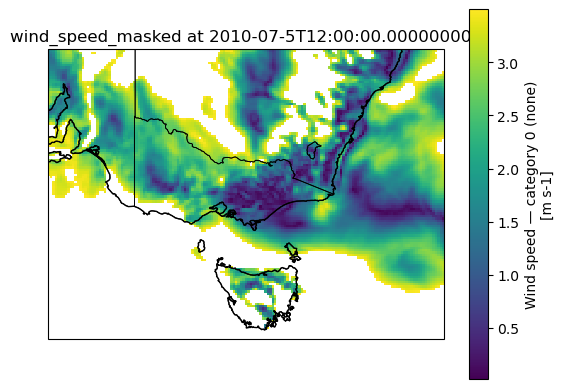

<Figure size 800x600 with 0 Axes>

In [29]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- USER INPUT ---
FILE = "/g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_speed_cats/barra_wind_cat0_none_2010.nc"   # add your file path
VAR  = "wind_speed_masked"   # variable to plot
TIME = "2010-07-5T12:00:00.000000000"   # timestep to plot
# -------------------

# Load dataset
ds = xr.open_dataset(FILE)

# Select timestep
da = ds[VAR].sel(time=TIME)

# Plot Set Up
ax = plt.axes(projection=ccrs.PlateCarree())
plt.figure(figsize=(8, 6))

# Call your data
da.plot(ax=ax, transform=ccrs.PlateCarree(),cmap="viridis")

# Add geographic context
ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.6)

# Labels + title
ax.set_title(f"{VAR} at {TIME}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

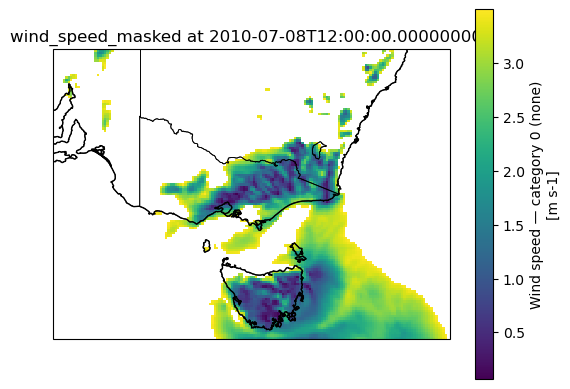

<Figure size 800x600 with 0 Axes>

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- USER INPUT ---
FILE = "/g/data/w42/ad1803/Coldwaves/Detrended_runs/SE_Aus_Run/Wind_blobs/Data/Wind_speed_cats/barra_wind_cat0_none_2010.nc"   # add your file path
VAR  = "wind_speed_masked"   # variable to plot
TIME = "2010-07-08T12:00:00.000000000"   # timestep to plot
# -------------------

# Load dataset
ds = xr.open_dataset(FILE)

# Select timestep
da = ds[VAR].sel(time=TIME)

# Plot Set Up
ax = plt.axes(projection=ccrs.PlateCarree())
plt.figure(figsize=(8, 6))

# Call your data
da.plot(ax=ax, transform=ccrs.PlateCarree(),cmap="viridis")

# Add geographic context
ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.6)

# Labels + title
ax.set_title(f"{VAR} at {TIME}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()